# 04 - Evaluation & Business Translation
Perubahan dari versi sebelumnya:
- Load model final & threshold dari model_metadata.json (tidak hardcode)
- Feature interpretation menggunakan SHAP TreeExplainer (model final = XGBoost, tree-based)
- Business translation menggunakan threshold optimal dari metadata

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    classification_report, fbeta_score, precision_recall_curve
)

sns.set_style("whitegrid")

In [16]:
with open("data/model_metadata.json", "r") as f:
    metadata = json.load(f)

MODEL_NAME = metadata["model_name"]
THRESHOLD  = metadata["threshold"]

print(f"Model final  : {MODEL_NAME}")
print(f"Threshold    : {THRESHOLD}")
print(f"Recall       : {metadata['recall']:.1%}")
print(f"ROC-AUC      : {metadata['roc_auc']}")
print(f"False Negative: {metadata['fn']}")

Model final  : XGBoost
Threshold    : 0.25
Recall       : 94.4%
ROC-AUC      : 0.8475
False Negative: 21


In [17]:
X_train = pd.read_csv("data/X_train.csv")
X_test  = pd.read_csv("data/X_test.csv")
y_train = pd.read_csv("data/y_train.csv").squeeze()
y_test  = pd.read_csv("data/y_test.csv").squeeze()

model   = joblib.load("data/model_final.pkl")
y_proba = np.load("data/y_proba_final.npy")
y_pred  = (y_proba >= THRESHOLD).astype(int)

# ============================================================

## 1. Confusion Matrix

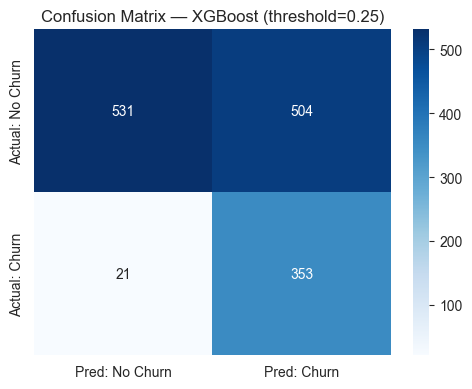


True Negative  (benar tidak churn) : 531
False Positive (false alarm)        : 504
False Negative (churn terlewat)     : 21  ← ingin diminimalkan
True Positive  (benar churn)        : 353

              precision    recall  f1-score   support

           0       0.96      0.51      0.67      1035
           1       0.41      0.94      0.57       374

    accuracy                           0.63      1409
   macro avg       0.69      0.73      0.62      1409
weighted avg       0.82      0.63      0.64      1409



In [18]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: No Churn", "Pred: Churn"],
    yticklabels=["Actual: No Churn", "Actual: Churn"]
)
plt.title(f"Confusion Matrix — {MODEL_NAME} (threshold={THRESHOLD})")
plt.tight_layout()
plt.show()

print(f"\nTrue Negative  (benar tidak churn) : {tn}")
print(f"False Positive (false alarm)        : {fp}")
print(f"False Negative (churn terlewat)     : {fn}  ← ingin diminimalkan")
print(f"True Positive  (benar churn)        : {tp}")
print(f"\n{classification_report(y_test, y_pred)}")

# ============================================================

## 2. ROC Curve & Precision-Recall Curve

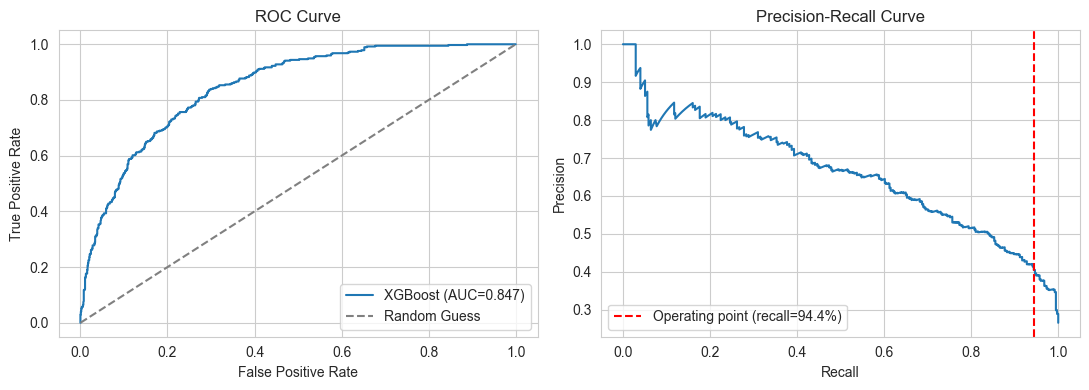

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f"{MODEL_NAME} (AUC={auc_score:.3f})")
axes[0].plot([0,1],[0,1], "--", color="gray", label="Random Guess")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# Precision-Recall Curve
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec_arr, prec_arr)
axes[1].axvline(metadata["recall"], color="red", linestyle="--",
                label=f"Operating point (recall={metadata['recall']:.1%})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================

## 3. Model Interpretation

Model final adalah XGBoost (tree-based, non-linear) — interpretasi
terbaik melalui SHAP (SHapley Additive exPlanations), bukan koefisien
linear (itu hanya berlaku untuk model seperti Logistic Regression).

SHAP menunjukkan kontribusi tiap fitur terhadap prediksi individual,
termasuk arah pengaruhnya: nilai fitur tinggi (titik merah) di sisi
kanan plot mendorong prediksi ke arah churn, di sisi kiri mendorong
ke arah tidak churn.

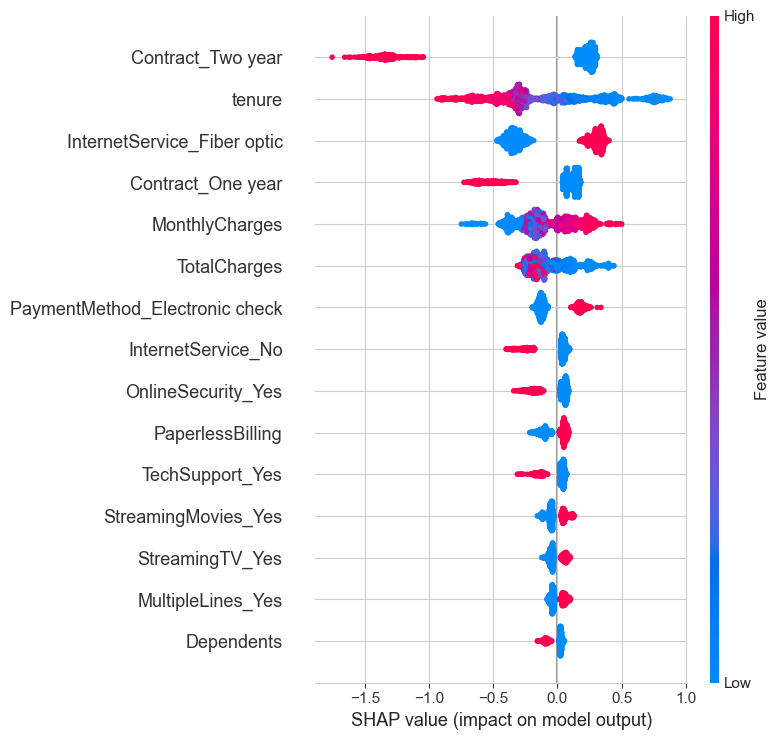

In [20]:
# Feature importance model final (XGBoost) pakai SHAP, bukan koefisien linear,
# karena XGBoost bukan model linear (tidak punya .coef_ / odds ratio).
# SHAP kasih tahu arah pengaruh tiap fitur (dorong ke arah churn / retensi)
# dan robust terhadap korelasi antar fitur, dibanding feature_importances_ biasa.
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=15)

In [21]:
importance_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X_test.columns
).sort_values(ascending=False).head(15)

importance_shap

Contract_Two year                 0.496734
tenure                            0.376300
InternetService_Fiber optic       0.323345
Contract_One year                 0.207167
MonthlyCharges                    0.198666
TotalCharges                      0.148329
PaymentMethod_Electronic check    0.145796
InternetService_No                0.096331
OnlineSecurity_Yes                0.091753
PaperlessBilling                  0.077108
TechSupport_Yes                   0.070195
StreamingMovies_Yes               0.061083
StreamingTV_Yes                   0.054372
MultipleLines_Yes                 0.046701
Dependents                        0.045518
dtype: float32

In [22]:
importance_table = pd.DataFrame({
    "Feature": importance_shap.index,
    "Mean_Abs_SHAP": importance_shap.round(4).values,
})
print("\nTop 15 Fitur — Mean Absolute SHAP Value:")
print(importance_table.to_string(index=False))


Top 15 Fitur — Mean Absolute SHAP Value:
                       Feature  Mean_Abs_SHAP
             Contract_Two year         0.4967
                        tenure         0.3763
   InternetService_Fiber optic         0.3233
             Contract_One year         0.2072
                MonthlyCharges         0.1987
                  TotalCharges         0.1483
PaymentMethod_Electronic check         0.1458
            InternetService_No         0.0963
            OnlineSecurity_Yes         0.0918
              PaperlessBilling         0.0771
               TechSupport_Yes         0.0702
           StreamingMovies_Yes         0.0611
               StreamingTV_Yes         0.0544
             MultipleLines_Yes         0.0467
                    Dependents         0.0455


Cara membaca Odds Ratio:
- OR > 1: fitur ini meningkatkan risiko churn. Contoh OR=2.5 artinya
  customer dengan fitur ini 2.5x lebih mungkin churn dibanding baseline.
- OR < 1: fitur ini menurunkan risiko churn. Contoh OR=0.3 artinya
  customer dengan fitur ini hanya 0.3x (lebih kecil) kemungkinan churn.
- OR = 1: fitur tidak berpengaruh pada probabilitas churn.

============================================================

## 4. Threshold Tuning Summary

In [23]:
rows = []
for t in [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]:
    pt  = (y_proba >= t).astype(int)
    cmt = confusion_matrix(y_test, pt)
    tnt, fpt, fnt, tpt = cmt.ravel()
    rec  = tpt / (tpt + fnt) if (tpt + fnt) > 0 else 0
    prec = tpt / (tpt + fpt) if (tpt + fpt) > 0 else 0
    f2   = fbeta_score(y_test, pt, beta=2)
    rows.append({
        "threshold": t,
        "recall": round(rec, 3),
        "precision": round(prec, 3),
        "f2": round(f2, 3),
        "FN": fnt,
        "FP": fpt,
        "selected": "← DIPILIH" if t == THRESHOLD else ""
    })

thr_table = pd.DataFrame(rows)
print("\nTrade-off di berbagai threshold:")
print(thr_table.to_string(index=False))

# ============================================================


Trade-off di berbagai threshold:
 threshold  recall  precision    f2  FN  FP  selected
      0.50   0.797      0.515 0.718  76 281          
      0.45   0.840      0.502 0.740  60 311          
      0.40   0.856      0.477 0.738  54 351          
      0.35   0.888      0.450 0.743  42 406          
      0.30   0.917      0.434 0.750  31 447          
      0.25   0.944      0.412 0.750  21 504 ← DIPILIH
      0.20   0.957      0.389 0.741  16 562          


## 5. Business Translation
============================================================

In [24]:
risk_df = pd.DataFrame({
    "actual_churn":    y_test.values,
    "churn_proba":     y_proba,
    "monthly_charges": X_test["MonthlyCharges"].values
})

def segment(p):
    if p >= 0.6:
        return "High Risk"
    elif p >= 0.35:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df["segment"] = risk_df["churn_proba"].apply(segment)

summary = risk_df.groupby("segment").agg(
    jumlah_customer   = ("actual_churn", "count"),
    actual_churn_rate = ("actual_churn", "mean"),
    avg_monthly_charges = ("monthly_charges", "mean")
).reindex(["High Risk", "Medium Risk", "Low Risk"]).round(3)

print("\nRisk Segmentation:")
print(summary)

# Validasi: churn rate harus monotonically decreasing High -> Medium -> Low
rates = summary["actual_churn_rate"].values
monotonic = all(rates[i] >= rates[i+1] for i in range(len(rates)-1)
                if not np.isnan(rates[i]) and not np.isnan(rates[i+1]))
print(f"\nMonotonic churn rate (validasi segmentasi): {'✓ Valid' if monotonic else '✗ Perlu review'}")


Risk Segmentation:
             jumlah_customer  actual_churn_rate  avg_monthly_charges
segment                                                             
High Risk                472              0.559               75.760
Medium Risk              266              0.256               69.815
Low Risk                 671              0.063               53.609

Monotonic churn rate (validasi segmentasi): ✓ Valid


In [25]:
high_risk        = risk_df[risk_df["segment"] == "High Risk"]
high_risk_churn  = high_risk[high_risk["actual_churn"] == 1]

success_rate     = 0.30
n_saved          = len(high_risk_churn) * success_rate
monthly_saved    = n_saved * high_risk_churn["monthly_charges"].mean() if len(high_risk_churn) > 0 else 0
annual_saved     = monthly_saved * 12

print(f"\nBusiness Impact Estimation:")
print(f"Customer High Risk              : {len(high_risk)}")
print(f"...yang benar-benar churn       : {len(high_risk_churn)}")
print(f"Estimasi terselamatkan (30%)    : {n_saved:.1f} customer")
print(f"Revenue terselamatkan / bulan   : ${monthly_saved:,.2f}")
print(f"Revenue terselamatkan / tahun   : ${annual_saved:,.2f}")


Business Impact Estimation:
Customer High Risk              : 472
...yang benar-benar churn       : 264
Estimasi terselamatkan (30%)    : 79.2 customer
Revenue terselamatkan / bulan   : $5,998.35
Revenue terselamatkan / tahun   : $71,980.20


## Ringkasan Akhir Project

Model Final : {MODEL_NAME}
Threshold   : {THRESHOLD}
ROC-AUC     : {metadata['roc_auc']}
Recall      : {metadata['recall']:.1%} ({tp} dari {tp+fn} customer churn terdeteksi)
False Neg   : {fn} customer churn tidak terdeteksi
False Pos   : {fp} false alarm (dapat retention offer tidak perlu)
Precision   : {metadata['precision']:.1%}

Rekomendasi Bisnis:
1. Fokus retention campaign pada segmen High Risk (probabilitas >= 0.6)
2. Tawarkan migrasi kontrak month-to-month -> tahunan dengan insentif
   (Contract_Two year adalah faktor protektif terkuat, odds ratio jauh < 1)
3. Program onboarding/loyalty untuk pelanggan baru (tenure rendah)
4. Evaluasi pricing/kualitas layanan Fiber optic
5. Dorong migrasi dari Electronic check ke pembayaran otomatis

Breakeven Sensitivity Analysis — Telco Churn
=============================================
Tujuan: threshold "optimal" tidak dikunci ke satu angka, karena itu
tergantung dua asumsi bisnis yang tidak ada di data: biaya retention
offer per customer, dan success rate offer tsb (berapa % yang
akhirnya batal churn setelah dikasih offer).
 
Cara pakai: paste ke notebook 04_evaluation.ipynb, sesuaikan path load
model/data kalau perlu (di sini asumsi dijalankan dari root repo).
 
Prioritas tetap: RECALL TINGGI + PR-AUC sebagai metrik utama (bukan
ROC-AUC) karena target imbalanced (374 churn / 1409 = 26.5%).
"""

=== Metrik Ranking Model (tidak tergantung threshold) ===
ROC-AUC : 0.8475
PR-AUC  : 0.6613  (baseline acak = 0.2654)
Lift PR-AUC vs baseline: 2.49x

=== Threshold Optimal per Skenario (baris=biaya $, kolom=success rate) ===
success_rate     0.1   0.2   0.3   0.4   0.5
cost_per_offer                              
5               0.10  0.10  0.10  0.10  0.10
10              0.25  0.10  0.10  0.10  0.10
20              0.45  0.25  0.25  0.10  0.10
35              0.45  0.45  0.25  0.25  0.25
50              0.50  0.45  0.45  0.30  0.25

=== Net Benefit ($) per Skenario ===
success_rate         0.1       0.2       0.3        0.4       0.5
cost_per_offer                                                   
5               27037.88  59515.76  91993.64  124471.52  156949.4
10              22559.08  54075.76  86553.64  119031.52  151509.4
20              15729.04  45118.16  76247.24  108151.52  140629.4
35               6354.04  34583.08  63392.24   94521.32  125650.4
50              -2364.78  

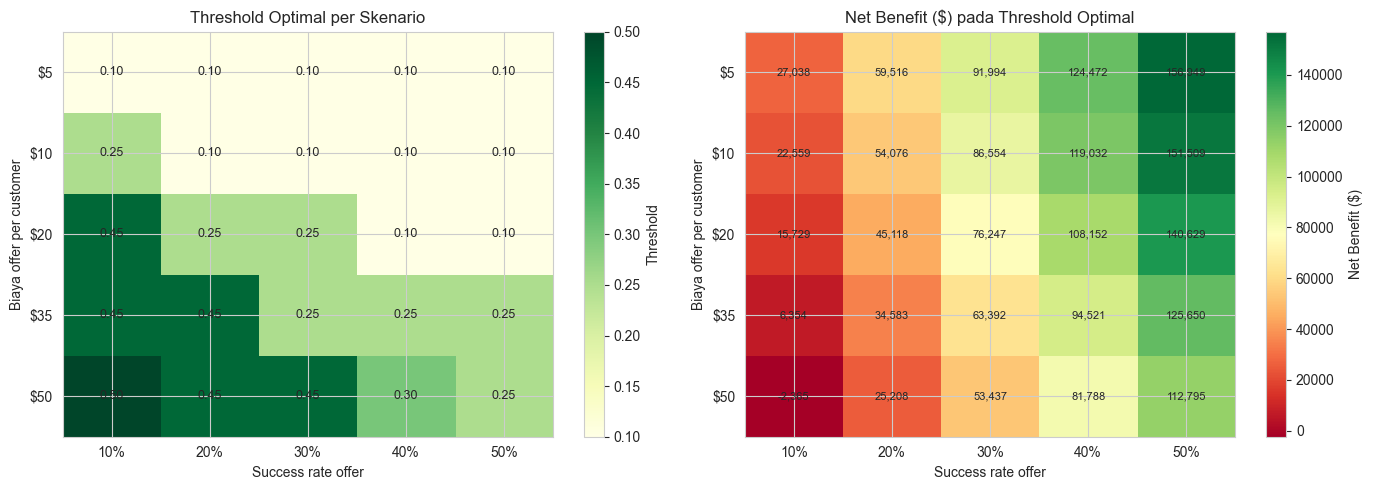


Heatmap disimpan: breakeven_sensitivity_heatmap.png


In [26]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    recall_score, precision_score, confusion_matrix
)
 
# ---------------------------------------------------------------
# 1. Load data real dari repo
# ---------------------------------------------------------------
y_test = pd.read_csv("data/y_test.csv").iloc[:, 0].values
y_proba = np.load("data/y_proba_final.npy")
X_test = pd.read_csv("data/X_test.csv")
monthly_charges = X_test["MonthlyCharges"].values  # revenue per customer, bukan rata-rata
 
# ---------------------------------------------------------------
# 2. Metrik ranking model (independen dari threshold & asumsi $)
#    -> ini yang dilaporkan sebagai "kualitas model"
# ---------------------------------------------------------------
pr_auc = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
baseline_pr_auc = y_test.mean()  # PR-AUC baseline classifier acak = prevalence kelas positif
 
print("=== Metrik Ranking Model (tidak tergantung threshold) ===")
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}  (baseline acak = {baseline_pr_auc:.4f})")
print(f"Lift PR-AUC vs baseline: {pr_auc / baseline_pr_auc:.2f}x")
print()
 
# ---------------------------------------------------------------
# 3. Sensitivity grid: biaya offer x success rate
# ---------------------------------------------------------------
cost_options = [5, 10, 20, 35, 50]          # biaya retention offer per customer ditarget ($)
success_rate_options = [0.10, 0.20, 0.30, 0.40, 0.50]  # % yang batal churn setelah offer
thresholds = np.round(np.arange(0.10, 0.55, 0.05), 2)
 
def net_benefit_at_threshold(threshold, cost_per_offer, success_rate):
    y_pred = (y_proba >= threshold).astype(int)
    tp_mask = (y_pred == 1) & (y_test == 1)
    fp_mask = (y_pred == 1) & (y_test == 0)
 
    tp_charges = monthly_charges[tp_mask]
    revenue_saved = (tp_charges * 12 * success_rate).sum()
 
    n_offers = tp_mask.sum() + fp_mask.sum()  # total customer yang dapat offer
    cost_total = n_offers * cost_per_offer
 
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
 
    return {
        "threshold": threshold,
        "n_TP": tp_mask.sum(),
        "n_FP": fp_mask.sum(),
        "n_offers": n_offers,
        "recall": recall,
        "precision": precision,
        "revenue_saved": revenue_saved,
        "cost_total": cost_total,
        "net_benefit": revenue_saved - cost_total,
    }
 
# ---------------------------------------------------------------
# 4. Cari threshold optimal per skenario (cost, success_rate)
# ---------------------------------------------------------------
results = []
for cost in cost_options:
    for sr in success_rate_options:
        scenario_results = [net_benefit_at_threshold(t, cost, sr) for t in thresholds]
        best = max(scenario_results, key=lambda r: r["net_benefit"])
        results.append({
            "cost_per_offer": cost,
            "success_rate": sr,
            "best_threshold": best["threshold"],
            "net_benefit": round(best["net_benefit"], 2),
            "recall": round(best["recall"], 3),
            "precision": round(best["precision"], 3),
            "n_offers": best["n_offers"],
        })
 
sensitivity_df = pd.DataFrame(results)
 
# Pivot jadi heatmap-ready table: threshold optimal per kombinasi
heatmap_threshold = sensitivity_df.pivot(
    index="cost_per_offer", columns="success_rate", values="best_threshold"
)
heatmap_netbenefit = sensitivity_df.pivot(
    index="cost_per_offer", columns="success_rate", values="net_benefit"
)
 
print("=== Threshold Optimal per Skenario (baris=biaya $, kolom=success rate) ===")
print(heatmap_threshold)
print()
print("=== Net Benefit ($) per Skenario ===")
print(heatmap_netbenefit)
print()
 
# ---------------------------------------------------------------
# 5. Dua skenario representatif untuk dilaporkan (bukan 1 angka tunggal)
# ---------------------------------------------------------------
conservative = net_benefit_at_threshold(threshold=0.30, cost_per_offer=35, success_rate=0.15)
optimistic = net_benefit_at_threshold(threshold=0.30, cost_per_offer=10, success_rate=0.35)
 
print("=== Skenario Konservatif (offer mahal $35, success rate rendah 15%) @ threshold 0.30 ===")
for k, v in conservative.items():
    print(f"  {k}: {v}")
print()
print("=== Skenario Optimis (offer murah $10, success rate tinggi 35%) @ threshold 0.30 ===")
for k, v in optimistic.items():
    print(f"  {k}: {v}")
print()
 
# ---------------------------------------------------------------
# 6. % customer base yang di-cover offer, di threshold 0.30 vs 0.50
# ---------------------------------------------------------------
for t in [0.30, 0.50]:
    y_pred = (y_proba >= t).astype(int)
    pct_targeted = y_pred.sum() / len(y_pred) * 100
    r = recall_score(y_test, y_pred)
    print(f"Threshold {t}: {y_pred.sum()} customer ditarget ({pct_targeted:.1f}% dari basis test), recall={r:.3f}")
 
# ---------------------------------------------------------------
# 7. Heatmap visual (2 panel: threshold optimal & net benefit)
# ---------------------------------------------------------------
import matplotlib.pyplot as plt
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
im0 = axes[0].imshow(heatmap_threshold.values, cmap="YlGn", aspect="auto")
axes[0].set_xticks(range(len(success_rate_options)))
axes[0].set_xticklabels([f"{s:.0%}" for s in success_rate_options])
axes[0].set_yticks(range(len(cost_options)))
axes[0].set_yticklabels([f"${c}" for c in cost_options])
axes[0].set_xlabel("Success rate offer")
axes[0].set_ylabel("Biaya offer per customer")
axes[0].set_title("Threshold Optimal per Skenario")
for i in range(len(cost_options)):
    for j in range(len(success_rate_options)):
        axes[0].text(j, i, f"{heatmap_threshold.values[i, j]:.2f}",
                     ha="center", va="center", fontsize=9)
plt.colorbar(im0, ax=axes[0], label="Threshold")
 
im1 = axes[1].imshow(heatmap_netbenefit.values, cmap="RdYlGn", aspect="auto")
axes[1].set_xticks(range(len(success_rate_options)))
axes[1].set_xticklabels([f"{s:.0%}" for s in success_rate_options])
axes[1].set_yticks(range(len(cost_options)))
axes[1].set_yticklabels([f"${c}" for c in cost_options])
axes[1].set_xlabel("Success rate offer")
axes[1].set_ylabel("Biaya offer per customer")
axes[1].set_title("Net Benefit ($) pada Threshold Optimal")
for i in range(len(cost_options)):
    for j in range(len(success_rate_options)):
        axes[1].text(j, i, f"{heatmap_netbenefit.values[i, j]:,.0f}",
                     ha="center", va="center", fontsize=8)
plt.colorbar(im1, ax=axes[1], label="Net Benefit ($)")
 
plt.tight_layout()
plt.savefig("breakeven_sensitivity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nHeatmap disimpan: breakeven_sensitivity_heatmap.png")